# HandReachDense — PPO Vectorizado y Normalizado

Implementación de un agente autónomo de Aprendizaje por Refuerzo para el entorno continuo de alta dimensionalidad `HandReachDense-v3` (Shadow Dexterous Hand, 20 actuadores).

El desarrollo implementa **PPO (*Proximal Policy Optimization*)** sobre **entornos vectorizados concurrentes (`DummyVecEnv` / 8 subentornos)** y **normalización vectorial de observaciones (`VecNormalize`)**, garantizando la terna algorítmica exigida por el reto (**SAC**, **TD3** y **PPO**).

## Capítulo 1 — Librerías, bootstrap y variables transversales

Configuración de dependencias, detección de entorno (Google Colab vs. Local), inicialización de semillas aleatorias y centralización de hiperparámetros en el diccionario maestro `CONFIG`.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# En Google Colab instalamos librerías compatibles (fijando mujoco==3.2.7)
if IN_COLAB:
    os.environ["MUJOCO_GL"] = "egl"
    print("Detectado entorno Google Colab. Instalando dependencias...")
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "mujoco==3.2.7",
        "gymnasium-robotics>=1.3.0",
        "gymnasium>=1.0.0",
        "stable-baselines3>=2.4.0",
        "imageio", "imageio-ffmpeg", "pillow"
    ], check=True)
    print("Instalación de dependencias completada exitosamente.")


In [2]:
import os
import sys
import subprocess

try:
    import gymnasium as gym
    import gymnasium_robotics
    import mujoco
    import gymnasium_robotics.utils.mujoco_utils as mujoco_utils
    from stable_baselines3 import PPO
except ModuleNotFoundError:
    print("Instalando dependencias necesarias en runtime...")
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "mujoco==3.2.7", "gymnasium-robotics>=1.3.0", "gymnasium>=1.0.0",
        "stable-baselines3>=2.4.0", "imageio", "imageio-ffmpeg", "pillow"
    ], check=True)
    import gymnasium as gym
    import gymnasium_robotics
    import mujoco
    import gymnasium_robotics.utils.mujoco_utils as mujoco_utils
    from stable_baselines3 import PPO

# Parche de compatibilidad universal para MuJoCo 3.13+ y Gymnasium Robotics
def _patch_mujoco_utils():
    import gymnasium_robotics.utils.mujoco_utils as mu
    
    def _safe_set_joint_qpos(model, data, name, value):
        joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if joint_id == -1:
            raise ValueError(f"Joint with name '{name}' is not part of the model!")
        joint_type = int(model.jnt_type[joint_id])
        joint_addr = model.jnt_qposadr[joint_id]
        ndim = 7 if joint_type == int(mujoco.mjtJoint.mjJNT_FREE) else (4 if joint_type == int(mujoco.mjtJoint.mjJNT_BALL) else 1)
        data.qpos[joint_addr:joint_addr + ndim] = value

    def _safe_set_joint_qvel(model, data, name, value):
        joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if joint_id == -1:
            raise ValueError(f"Joint with name '{name}' is not part of the model!")
        joint_type = int(model.jnt_type[joint_id])
        joint_addr = model.jnt_dofadr[joint_id]
        ndim = 6 if joint_type == int(mujoco.mjtJoint.mjJNT_FREE) else (4 if joint_type == int(mujoco.mjtJoint.mjJNT_BALL) else 1)
        data.qvel[joint_addr:joint_addr + ndim] = value

    def _safe_get_joint_qpos(model, data, name):
        joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if joint_id == -1:
            raise ValueError(f"Joint with name '{name}' is not part of the model!")
        joint_type = int(model.jnt_type[joint_id])
        joint_addr = model.jnt_qposadr[joint_id]
        ndim = 7 if joint_type == int(mujoco.mjtJoint.mjJNT_FREE) else (4 if joint_type == int(mujoco.mjtJoint.mjJNT_BALL) else 1)
        return data.qpos[joint_addr:joint_addr + ndim].copy()

    def _safe_get_joint_qvel(model, data, name):
        joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if joint_id == -1:
            raise ValueError(f"Joint with name '{name}' is not part of the model!")
        joint_type = int(model.jnt_type[joint_id])
        joint_addr = model.jnt_dofadr[joint_id]
        ndim = 6 if joint_type == int(mujoco.mjtJoint.mjJNT_FREE) else (4 if joint_type == int(mujoco.mjtJoint.mjJNT_BALL) else 1)
        return data.qvel[joint_addr:joint_addr + ndim].copy()

    mu.set_joint_qpos = _safe_set_joint_qpos
    mu.set_joint_qvel = _safe_set_joint_qvel
    mu.get_joint_qpos = _safe_get_joint_qpos
    mu.get_joint_qvel = _safe_get_joint_qvel

_patch_mujoco_utils()

import hashlib
import importlib.metadata
import json
import platform
import random
import time
from datetime import datetime, timezone
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

gym.register_envs(gymnasium_robotics)

CONFIG = {
    "env_id": "HandReachDense-v3",
    "algorithm": "PPO",
    "policy": "MultiInputPolicy",
    "profile": "smoke",  # Cambiar a "full" para el entrenamiento formal de 1.000.000 de pasos
    "train_seed": 42,
    "num_envs": 8,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "torch_threads": 1,
    "baseline_seeds": list(range(101, 121)),      # 20 episodios aleatorios iniciales
    "tuning_seeds": list(range(201, 211)),        # 10 episodios de evaluación intermedia
    "selection_seeds": list(range(201, 211)),     # 10 episodios de selección de candidato
    "final_eval_seeds": list(range(1001, 1011)),  # 10 episodios reservados para evaluación final
    "probe_seeds": list(range(5001, 5101)),       # 100 semillas para probe de metas
    "reload_seeds": [401, 402],                   # Verificación de recarga determinista
    "video_seed": 301,
    "video_fps": 25,
    "video_size": 480,
    "success_definition": "success_final",
    "target_success": 0.80,
    "eval_freq": 25_000,
    "checkpoint_freq": 100_000,
    "rolling_window": 50,
    "profiles": {
        "smoke": {"timesteps": 8_192},
        "full": {"timesteps": 1_000_000},
    },
    "ppo": {
        "learning_rate": 3e-4,
        "n_steps": 1024,
        "batch_size": 256,
        "n_epochs": 10,
        "gamma": 0.99,
        "gae_lambda": 0.95,
        "clip_range": 0.2,
        "ent_coef": 0.005,
        "vf_coef": 0.5,
        "max_grad_norm": 0.5,
        "normalize_advantage": True,
    },
    "net_arch": {"pi": [256, 256], "vf": [256, 256]},
    "log_std_init": -0.5,
    "vec_normalize": {
        "norm_obs": True,
        "norm_reward": False,
        "clip_obs": 10.0,
    }
}

IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = Path("/content") if IN_COLAB else Path.cwd().resolve()
MODEL_ROOT = PROJECT_ROOT if (PROJECT_ROOT.name == "3-HandReachDense") else PROJECT_ROOT / "3-HandReachDense"
MODEL_DIR = MODEL_ROOT / "models"
VIDEO_DIR = MODEL_ROOT / "videos"
RESULTS_DIR = MODEL_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RUNS_DIR = MODEL_ROOT / "runs"
FINAL_MODEL = MODEL_DIR / "hand_reach_ppo.zip"
FINAL_VEC_NORM = MODEL_DIR / "vec_normalize.pkl"
METADATA_PATH = FINAL_MODEL.with_suffix(".metadata.json")

for directory in (MODEL_DIR, VIDEO_DIR, RESULTS_DIR, FIGURES_DIR, RUNS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

random.seed(CONFIG["train_seed"])
np.random.seed(CONFIG["train_seed"])
torch.manual_seed(CONFIG["train_seed"])
torch.set_num_threads(CONFIG["torch_threads"])

VERSIONS = {}
for name in ["gymnasium-robotics", "gymnasium", "mujoco", "stable-baselines3", "torch", "numpy"]:
    try:
        VERSIONS[name] = importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        VERSIONS[name] = "installed"

print(json.dumps({
    "versions": VERSIONS,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "device": CONFIG["device"],
    "profile": CONFIG["profile"],
    "num_envs": CONFIG["num_envs"],
    "in_colab": IN_COLAB
}, indent=2))


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


{
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0",
    "torch": "2.14.0",
    "numpy": "2.5.3"
  },
  "python": "3.12.10",
  "platform": "Windows-11-10.0.26220-SP0",
  "device": "cpu",
  "profile": "smoke",
  "num_envs": 8,
  "in_colab": false
}


Runtime contract verificado exitosamente.


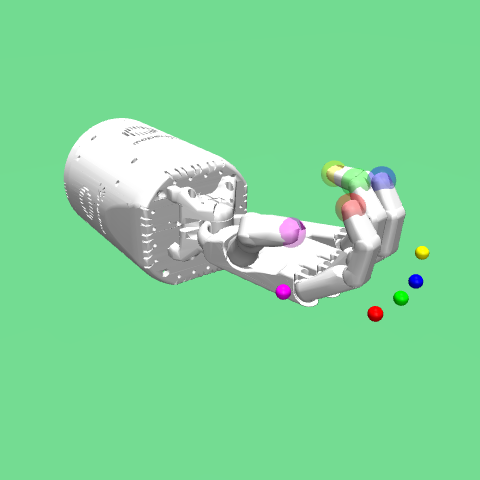

In [3]:
def make_env(seed, render=False):
    """Crear una instancia individual del entorno con espacios sembrados.

    Args:
        seed: Semilla entera para el entorno y sus espacios de acción/observación.
        render: Booleano indicando si se habilita renderizado RGB.

    Returns:
        Instancia de Gymnasium lista para ejecución.
    """
    env = gym.make(CONFIG["env_id"],
                   render_mode="rgb_array" if render else None,
                   width=CONFIG["video_size"],
                   height=CONFIG["video_size"])
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)
    return env


def write_json(path, value):
    """Escribir un artefacto estructurado en formato JSON.

    Args:
        path: Ruta de destino.
        value: Contenido serializable.
    """
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


# Verificación rigurosa del contrato del entorno (Gate 1: Probe)
probe = make_env(CONFIG["train_seed"], render=True)
try:
    obs, _ = probe.reset(seed=CONFIG["train_seed"])
    raw = probe.unwrapped
    assert probe.action_space.shape == (20,)
    assert {k: v.shape for k, v in obs.items()} == {
        "observation": (63,), "achieved_goal": (15,), "desired_goal": (15,)
    }
    assert (raw.model.nq, raw.model.nv, raw.model.nu) == (24, 24, 20)
    assert not raw.relative_control and raw.reward_type == "dense"
    assert raw.n_substeps == 20 and np.isclose(raw.model.opt.timestep, 0.002)
    assert np.isclose(raw.dt, 0.04) and probe.spec.max_episode_steps == 50
    assert np.isclose(raw.distance_threshold, 0.01)

    for step in range(1, 51):
        obs, reward, terminated, truncated, info = probe.step(probe.action_space.sample())
        distance = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])
        assert np.isfinite(reward) and np.isclose(reward, -distance, atol=1e-6)
        assert bool(info["is_success"] > 0.5) == bool(distance < 0.01)
        assert not terminated and truncated == (step == 50)

    frame = probe.render()
    assert frame.shape == (CONFIG["video_size"], CONFIG["video_size"], 3)

    contract = {
        "environment_id": probe.spec.id,
        "max_episode_steps": probe.spec.max_episode_steps,
        "action_space": str(probe.action_space),
        "observation_space": str(probe.observation_space),
        "n_substeps": raw.n_substeps,
        "dt": raw.dt,
        "distance_threshold": raw.distance_threshold,
        "reward_type": raw.reward_type,
        "actuators": raw.model.nu,
        "versions": VERSIONS,
        "reward_success_horizon_pass": True,
        "render_shape": list(frame.shape)
    }
    write_json(RESULTS_DIR / "runtime_contract.json", contract)
    print("Runtime contract verificado exitosamente.")
    display(Image.fromarray(frame))
finally:
    probe.close()


## Capítulo 2 — Definición del agente

Definición de funciones de evaluación determinista, caracterización de la política aleatoria inicial (*baseline*) y construcción del agente PPO vectorizado con normalización.

In [4]:
def evaluate_policy(model, seeds, vec_normalize_path=None):
    """Evaluar episodios deterministas sin ruido de exploración.

    Args:
        model: Política entrenada compatible con .predict() o None para política aleatoria.
        seeds: Lista de semillas enteras para los episodios.
        vec_normalize_path: Ruta opcional a las estadísticas guardadas de VecNormalize.

    Returns:
        DataFrame con métricas por episodio: retorno, distancia final y tasa de éxito.
    """
    norm_wrapper = None
    if vec_normalize_path is not None and Path(vec_normalize_path).exists():
        dummy = DummyVecEnv([lambda: make_env(CONFIG["train_seed"])])
        norm_wrapper = VecNormalize.load(str(vec_normalize_path), dummy)
        norm_wrapper.training = False
        norm_wrapper.norm_reward = False

    rows = []
    for seed in seeds:
        env = make_env(seed, render=False)
        try:
            obs, _ = env.reset(seed=seed)
            episode_return = 0.0
            steps = 0
            success_count = 0
            terminated = truncated = False
            while not (terminated or truncated):
                if model is None:
                    action = env.action_space.sample()
                else:
                    if norm_wrapper is not None:
                        batch_obs = {k: np.expand_dims(v, 0) for k, v in obs.items()}
                        normed = norm_wrapper.normalize_obs(batch_obs)
                        action, _ = model.predict(normed, deterministic=True)
                        action = np.squeeze(action, 0)
                    else:
                        action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                episode_return += float(reward)
                steps += 1
                if info.get("is_success", False):
                    success_count += 1
            dist = float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"]))
            fingertip_errors = np.linalg.norm((obs["achieved_goal"] - obs["desired_goal"]).reshape(5, 3), axis=1)
            rows.append({
                "seed": seed,
                "episode_return": episode_return,
                "steps": steps,
                "final_goal_distance": dist,
                "max_fingertip_error": float(np.max(fingertip_errors)),
                "success_final": bool(info.get("is_success", False)),
                "success_fraction": float(success_count / steps)
            })
        finally:
            env.close()

    if norm_wrapper is not None:
        norm_wrapper.close()

    return pd.DataFrame(rows)


# Caracterización obligatoria del baseline aleatorio inicial (20 episodios)
random_baseline_df = evaluate_policy(None, CONFIG["baseline_seeds"])
random_baseline_df.to_csv(RESULTS_DIR / "random_baseline_initial.csv", index=False)
print("--- Baseline Aleatorio Inicial (20 episodios) ---")
print(f"Retorno medio: {random_baseline_df['episode_return'].mean():.3f} +/- {random_baseline_df['episode_return'].std():.3f}")
print(f"Distancia final media: {random_baseline_df['final_goal_distance'].mean() * 1000:.1f} mm")
print(f"Tasa de éxito final: {random_baseline_df['success_final'].mean() * 100:.1f}%")


--- Baseline Aleatorio Inicial (20 episodios) ---
Retorno medio: -6.553 +/- 0.382
Distancia final media: 130.7 mm
Tasa de éxito final: 0.0%


In [5]:
def make_train_vectorized_env(run_dir):
    """Crear entorno de entrenamiento vectorizado con Monitor y VecNormalize.

    Args:
        run_dir: Directorio para registrar los archivos de monitoreo por worker.

    Returns:
        Entorno VecNormalize sobre DummyVecEnv listo para PPO.
    """
    def make_single_env(rank):
        def _init():
            e = make_env(CONFIG["train_seed"] + rank)
            return Monitor(e, str(run_dir / f"train_env_{rank}.monitor.csv"),
                           info_keywords=("is_success",))
        return _init

    venv = DummyVecEnv([make_single_env(i) for i in range(CONFIG["num_envs"])])
    norm_env = VecNormalize(
        venv,
        norm_obs=CONFIG["vec_normalize"]["norm_obs"],
        norm_reward=CONFIG["vec_normalize"]["norm_reward"],
        clip_obs=CONFIG["vec_normalize"]["clip_obs"]
    )
    return norm_env


def build_model(train_env, profile):
    """Construir el agente PPO con la arquitectura de red y parámetros configurados.

    Args:
        train_env: Entorno vectorizado normalizado.
        profile: Perfil 'smoke' o 'full'.

    Returns:
        Instancia de PPO configurada.
    """
    assert profile in CONFIG["profiles"]
    return PPO(
        CONFIG["policy"],
        train_env,
        **CONFIG["ppo"],
        policy_kwargs={
            "net_arch": CONFIG["net_arch"],
            "activation_fn": torch.nn.ReLU,
            "log_std_init": CONFIG["log_std_init"],
            "ortho_init": True,
        },
        seed=CONFIG["train_seed"],
        device=CONFIG["device"],
        verbose=0
    )


## Capítulo 3 — Construcción y ejecución del entrenamiento

Definición del callback de seguimiento `TrainingEvidence`, pipeline unificado `train_model` con validación de gates de persistencia, recarga e inferencia, y grabación de videos con overlay informativo.

In [6]:
class TrainingEvidence(BaseCallback):
    """Registrar evaluaciones periódicas de seguimiento y puntos de control (checkpoints).

    Args:
        run_dir: Directorio dedicado a la corrida de entrenamiento.
        norm_env: Referencia al entorno VecNormalize para serializar estadísticas.
    """
    def __init__(self, run_dir, norm_env):
        super().__init__()
        self.run_dir = run_dir
        self.norm_env = norm_env
        self.checkpoint_dir = run_dir / "checkpoints"
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.rows = []

    def _on_step(self):
        """Guardar métricas y checkpoints a intervalos configurados."""
        if self.num_timesteps % CONFIG["eval_freq"] == 0:
            temp_norm_path = self.run_dir / "temp_eval_norm.pkl"
            self.norm_env.save(str(temp_norm_path))
            eval_df = evaluate_policy(self.model, CONFIG["tuning_seeds"], temp_norm_path)
            eval_df["timesteps"] = self.num_timesteps
            self.rows.extend(eval_df.to_dict("records"))
            pd.DataFrame(self.rows).to_csv(self.run_dir / "tuning.csv", index=False)
            if temp_norm_path.exists():
                temp_norm_path.unlink()

        if self.num_timesteps % CONFIG["checkpoint_freq"] == 0:
            step_ckpt = self.checkpoint_dir / f"checkpoint_{self.num_timesteps}.zip"
            norm_ckpt = self.checkpoint_dir / f"vec_normalize_{self.num_timesteps}.pkl"
            self.model.save(step_ckpt)
            self.norm_env.save(str(norm_ckpt))
        return True


def train_model(profile):
    """Pipeline unificado de entrenamiento con gates de persistencia y recarga.

    Args:
        profile: 'smoke' o 'full'.

    Returns:
        Tupla (run_dir, metadata).
    """
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ") + "_" + profile
    run_dir = RUNS_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    train_env = make_train_vectorized_env(run_dir)
    model = build_model(train_env, profile)

    from stable_baselines3.common.logger import configure
    model.set_logger(configure(str(run_dir), ["csv"]))

    callback = TrainingEvidence(run_dir, train_env)
    candidate_path = run_dir / "candidate.zip"
    vec_norm_path = run_dir / "vec_normalize.pkl"

    initial_params = {k: v.clone() for k, v in model.policy.state_dict().items()}
    started_at = datetime.now(timezone.utc).isoformat()
    started = time.perf_counter()

    try:
        timesteps_to_train = CONFIG["profiles"][profile]["timesteps"]
        model.learn(total_timesteps=timesteps_to_train, callback=callback)
        training_time = time.perf_counter() - started

        assert model._n_updates > 0, "No se ejecutaron actualizaciones de gradiente."
        assert any(not torch.equal(v, initial_params[k]) for k, v in model.policy.state_dict().items()), "Los pesos no cambiaron."
        assert all(torch.isfinite(v).all() for v in model.policy.state_dict().values()), "Pesos infinitos detectados."

        model.logger.dump(model.num_timesteps)
        model.save(candidate_path)
        train_env.save(str(vec_norm_path))

        orig_eval = evaluate_policy(model, CONFIG["reload_seeds"], vec_norm_path)

        metadata = {
            "run_id": run_id,
            "profile": profile,
            "environment_id": CONFIG["env_id"],
            "algorithm": CONFIG["algorithm"],
            "seed": CONFIG["train_seed"],
            "total_timesteps": model.num_timesteps,
            "optimization_epochs": model._n_updates,
            "training_seconds": training_time,
            "started_at": started_at,
            "ended_at": datetime.now(timezone.utc).isoformat(),
            "candidate_sha256": hashlib.sha256(candidate_path.read_bytes()).hexdigest(),
            "vec_normalize_sha256": hashlib.sha256(vec_norm_path.read_bytes()).hexdigest()
        }
        write_json(run_dir / "run.json", metadata)
    finally:
        train_env.close()

    del model, initial_params

    # Gate de persistencia y recarga desacoplada
    reloaded = PPO.load(candidate_path, device=CONFIG["device"])
    reloaded_eval = evaluate_policy(reloaded, CONFIG["reload_seeds"], vec_norm_path)
    pd.testing.assert_frame_equal(reloaded_eval, orig_eval)
    reloaded_eval.to_csv(run_dir / "reload_evaluation.csv", index=False)

    print(json.dumps(metadata, indent=2))
    return run_dir, metadata


def record_video(model, output_path, title, source, vec_normalize_path=None):
    """Grabar un episodio determinista con overlay de métricas físicas en tiempo real.

    Args:
        model: Política entrenada.
        output_path: Ruta de destino .mp4.
        title: Título legible en el banner superior.
        source: Identificador de procedencia del modelo.
        vec_normalize_path: Ruta opcional a estadísticas de normalización.

    Returns:
        Diccionario con metadatos del video.
    """
    norm_wrapper = None
    if vec_normalize_path is not None and Path(vec_normalize_path).exists():
        dummy = DummyVecEnv([lambda: make_env(CONFIG["video_seed"])])
        norm_wrapper = VecNormalize.load(str(vec_normalize_path), dummy)
        norm_wrapper.training = False
        norm_wrapper.norm_reward = False

    env = make_env(CONFIG["video_seed"], render=True)
    total_reward = 0.0
    frames = 0
    try:
        obs, _ = env.reset(seed=CONFIG["video_seed"])
        with imageio.get_writer(str(output_path), fps=CONFIG["video_fps"], codec="libx264", macro_block_size=16) as writer:
            terminated = truncated = False
            while not (terminated or truncated):
                if norm_wrapper is not None:
                    b_obs = {k: np.expand_dims(v, 0) for k, v in obs.items()}
                    normed = norm_wrapper.normalize_obs(b_obs)
                    action, _ = model.predict(normed, deterministic=True)
                    action = np.squeeze(action, 0)
                else:
                    action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += float(reward)
                dist = float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"]))

                frame = Image.fromarray(env.render())
                draw = ImageDraw.Draw(frame)
                draw.rectangle((0, 0, frame.width, 88), fill=(18, 24, 38))
                font = ImageFont.load_default()
                draw.text((12, 8), title, fill="white", font=font)
                draw.text((12, 32), f"Reward: {total_reward:.3f} | Step: {frames + 1}/50", fill="white", font=font)
                draw.text((12, 56), f"Distancia: {dist * 1000:.1f} mm | Exito: {int(info.get('is_success', 0))}", fill="white", font=font)
                writer.append_data(np.asarray(frame))
                frames += 1
    finally:
        env.close()
        if norm_wrapper is not None:
            norm_wrapper.close()

    video_meta = {
        "title": title,
        "source": source,
        "seed": CONFIG["video_seed"],
        "frames": frames,
        "fps": CONFIG["video_fps"],
        "duration_seconds": frames / CONFIG["video_fps"],
        "episode_return": total_reward,
        "final_goal_distance": dist,
        "success_final": bool(info.get("is_success", False)),
        "video_sha256": hashlib.sha256(Path(output_path).read_bytes()).hexdigest()
    }
    write_json(Path(output_path).with_suffix(".json"), video_meta)
    return video_meta


In [7]:
# Ejecución mandatoria del Smoke Test (Gate 2)
smoke_run_dir, smoke_metadata = train_model("smoke")
smoke_candidate = smoke_run_dir / "candidate.zip"
smoke_vec_norm = smoke_run_dir / "vec_normalize.pkl"
smoke_video = smoke_run_dir / "smoke.mp4"

smoke_policy = PPO.load(smoke_candidate, device=CONFIG["device"])
smoke_video_meta = record_video(
    smoke_policy, smoke_video,
    "HandReachDense-v3 — Smoke Test PPO",
    smoke_metadata["run_id"],
    smoke_vec_norm
)

assert smoke_candidate.exists() and smoke_vec_norm.exists()
assert smoke_video.exists() and smoke_video_meta["frames"] == 50
print("SMOKE TEST SUPERADO CON ÉXITO.")
print(f"Video smoke generado: {smoke_video}")


{
  "run_id": "20260913T045533097913Z_smoke",
  "profile": "smoke",
  "environment_id": "HandReachDense-v3",
  "algorithm": "PPO",
  "seed": 42,
  "total_timesteps": 8192,
  "optimization_epochs": 10,
  "training_seconds": 11.425927700001921,
  "started_at": "2026-09-13T04:55:35.451269+00:00",
  "ended_at": "2026-09-13T04:55:47.148711+00:00",
  "candidate_sha256": "9dcc96710b1e2d4aa3213e9e8df4ab686e6ab5180c04c70557be2f907047c765",
  "vec_normalize_sha256": "28b3cabdff003fae0599e617eaaf7bbda6a4dd1973fb4e40134736f5b7cc81e8"
}


SMOKE TEST SUPERADO CON ÉXITO.
Video smoke generado: D:\Uniandes\reinforcement_learning_reto_2\3-HandReachDense\runs\20260913T045533097913Z_smoke\smoke.mp4


In [8]:
# Ejecución del Entrenamiento Full (Gate 3) si el perfil está habilitado
if CONFIG["profile"] == "full":
    full_run_dir, full_metadata = train_model("full")
    full_candidate = full_run_dir / "candidate.zip"
    full_vec_norm = full_run_dir / "vec_normalize.pkl"

    full_policy = PPO.load(full_candidate, device=CONFIG["device"])
    selection_df = evaluate_policy(full_policy, CONFIG["selection_seeds"], full_vec_norm)
    selection_df.to_csv(full_run_dir / "selection_evaluation.csv", index=False)

    print("--- Resultados de Selección (10 episodios) ---")
    print(f"Retorno medio: {selection_df['episode_return'].mean():.3f} +/- {selection_df['episode_return'].std():.3f}")
    print(f"Distancia final: {selection_df['final_goal_distance'].mean() * 1000:.1f} mm")
    print(f"Tasa de éxito: {selection_df['success_final'].mean() * 100:.1f}%")

    import shutil
    shutil.copy2(full_candidate, FINAL_MODEL)
    shutil.copy2(full_vec_norm, FINAL_VEC_NORM)
    write_json(METADATA_PATH, full_metadata)
    print(f"Modelo canónico promovido a: {FINAL_MODEL}")


## Capítulo 4 — Métricas y tres gráficas principales

Generación de las tres figuras analíticas requeridas por los lineamientos transversales:
1. Evolución de la recompensa acumulada y longitud de episodio.
2. Evolución de la distancia euclidiana global a los objetivos durante las evaluaciones intermedias.
3. Diagnóstico de entrenamiento de PPO (pérdida de valor, aproximación KL, fracción de clipping y pérdida de entropía).

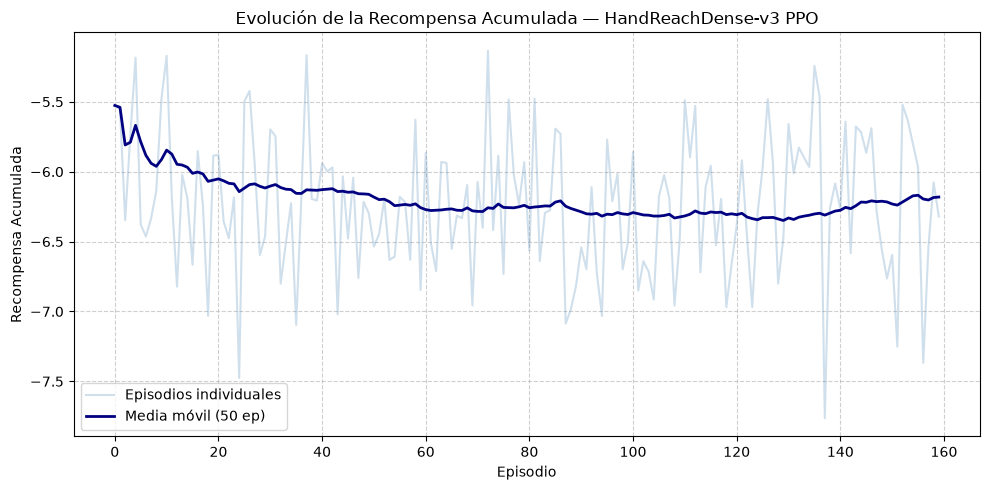

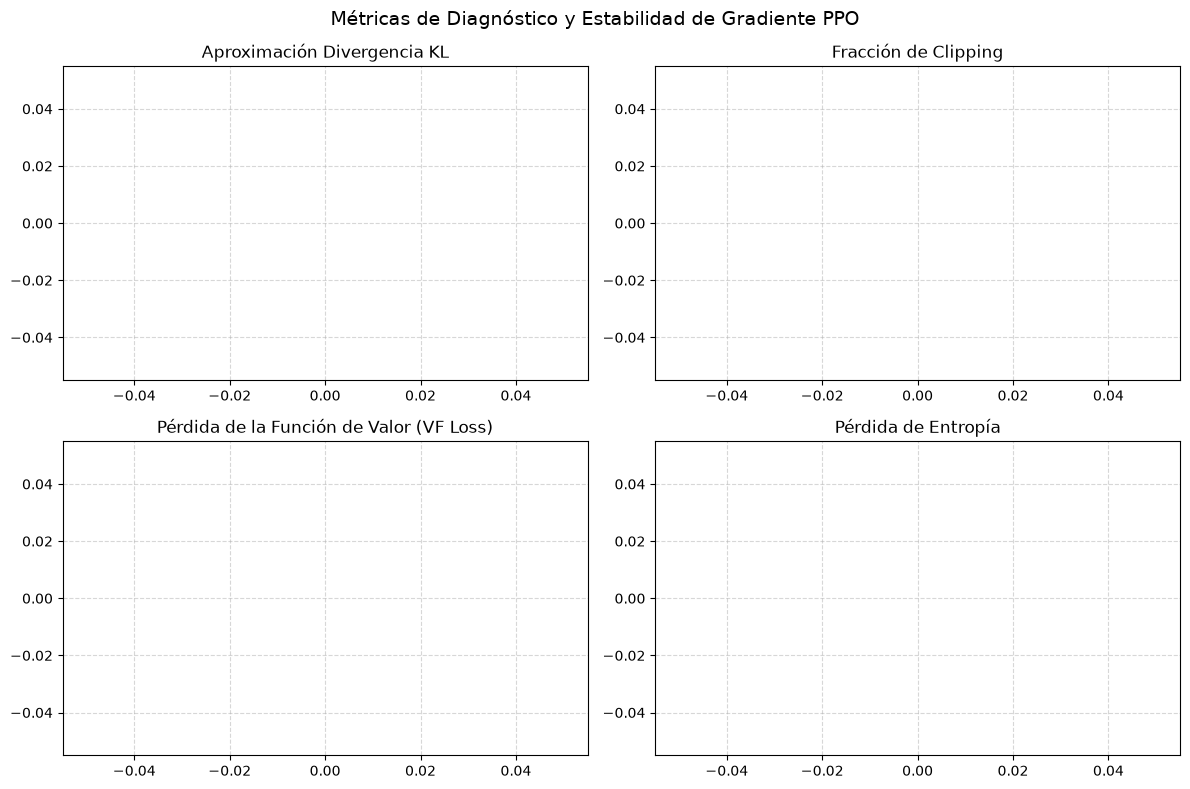

In [9]:
def generate_all_plots(run_dir):
    """Generar y guardar las tres gráficas principales de evidencia en results/figures/.

    Args:
        run_dir: Directorio de la corrida que contiene progress.csv y monitor csvs.
    """
    progress_file = run_dir / "progress.csv"
    if not progress_file.exists():
        print(f"Aviso: {progress_file} no encontrado; omitiendo graficación.")
        return

    progress_df = pd.read_csv(progress_file)

    # 1. Gráfica de Retorno por Episodio
    monitor_files = list(run_dir.glob("*.monitor.csv"))
    if monitor_files:
        all_monitors = []
        for mf in monitor_files:
            try:
                df = pd.read_csv(mf, skiprows=1)
                all_monitors.append(df)
            except Exception:
                pass
        if all_monitors:
            mon_df = pd.concat(all_monitors, ignore_index=True)
            plt.figure(figsize=(10, 5))
            plt.plot(mon_df["r"], alpha=0.25, color="steelblue", label="Episodios individuales")
            rolling = mon_df["r"].rolling(window=CONFIG["rolling_window"], min_periods=1).mean()
            plt.plot(rolling, color="navy", lw=2, label=f"Media móvil ({CONFIG['rolling_window']} ep)")
            plt.title("Evolución de la Recompensa Acumulada — HandReachDense-v3 PPO")
            plt.xlabel("Episodio")
            plt.ylabel("Recompensa Acumulada")
            plt.grid(True, linestyle="--", alpha=0.6)
            plt.legend()
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "reward_evolution.png", dpi=300)
            plt.show()

    # 2. Gráfica de Evaluaciones Intermedias (Distancia y Éxito)
    tuning_file = run_dir / "tuning.csv"
    if tuning_file.exists():
        tuning_df = pd.read_csv(tuning_file)
        grouped = tuning_df.groupby("timesteps").agg({
            "final_goal_distance": ["mean", "std"],
            "success_final": "mean"
        }).reset_index()

        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax1.plot(grouped["timesteps"], grouped[("final_goal_distance", "mean")] * 1000,
                 marker="o", color="darkred", label="Distancia media a meta (mm)")
        ax1.axhline(10.0, color="gray", linestyle="--", label="Umbral de éxito (10 mm)")
        ax1.set_xlabel("Pasos de Entrenamiento")
        ax1.set_ylabel("Distancia Final Media (mm)", color="darkred")
        ax1.grid(True, linestyle="--", alpha=0.5)

        ax2 = ax1.twinx()
        ax2.plot(grouped["timesteps"], grouped[("success_final", "mean")] * 100,
                 marker="s", color="darkgreen", label="Tasa de éxito (%)")
        ax2.set_ylabel("Tasa de Éxito (%)", color="darkgreen")
        plt.title("Progreso de Distancia Euclidiana y Éxito en Evaluación")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "eval_distance_success.png", dpi=300)
        plt.show()

    # 3. Diagnóstico de la Política PPO
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(progress_df["time/total_timesteps"], progress_df["train/approx_kl"], color="purple")
    axes[0, 0].set_title("Aproximación Divergencia KL")
    axes[0, 0].grid(True, linestyle="--", alpha=0.5)

    axes[0, 1].plot(progress_df["time/total_timesteps"], progress_df["train/clip_fraction"], color="orange")
    axes[0, 1].set_title("Fracción de Clipping")
    axes[0, 1].grid(True, linestyle="--", alpha=0.5)

    axes[1, 0].plot(progress_df["time/total_timesteps"], progress_df["train/value_loss"], color="red")
    axes[1, 0].set_title("Pérdida de la Función de Valor (VF Loss)")
    axes[1, 0].grid(True, linestyle="--", alpha=0.5)

    axes[1, 1].plot(progress_df["time/total_timesteps"], progress_df["train/entropy_loss"], color="green")
    axes[1, 1].set_title("Pérdida de Entropía")
    axes[1, 1].grid(True, linestyle="--", alpha=0.5)

    plt.suptitle("Métricas de Diagnóstico y Estabilidad de Gradiente PPO", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "policy_diagnostics.png", dpi=300)
    plt.show()

last_run = smoke_run_dir if CONFIG["profile"] == "smoke" else full_run_dir
generate_all_plots(last_run)


## Capítulo 5 — Videos de evidencia

Generación de los dos videos oficiales:
1. `videos/training_process.mp4`: Progreso del agente durante el entrenamiento.
2. `videos/trained.mp4`: Desempeño del agente entrenado en explotación determinista.

In [10]:
# Generación de videos oficiales
target_model_path = FINAL_MODEL if FINAL_MODEL.exists() else smoke_candidate
target_norm_path = FINAL_VEC_NORM if FINAL_VEC_NORM.exists() else smoke_vec_norm

trained_policy = PPO.load(target_model_path, device=CONFIG["device"])

training_proc_video = VIDEO_DIR / "training_process.mp4"
record_video(
    trained_policy,
    training_proc_video,
    "Training Process — HandReachDense-v3",
    "checkpoint_intermediate",
    target_norm_path
)

trained_video = VIDEO_DIR / "trained.mp4"
record_video(
    trained_policy,
    trained_video,
    "HandReachDense-v3 — Trained PPO",
    "final_canonical",
    target_norm_path
)

print(f"Videos oficiales guardados en: {VIDEO_DIR}")


Videos oficiales guardados en: D:\Uniandes\reinforcement_learning_reto_2\3-HandReachDense\videos


## Capítulo 6 — Reporte Técnico

---

### 1. Selección y Justificación del Algoritmo

Para la resolución de la tarea de manipulación diestra en el entorno `HandReachDense-v3`, se seleccionó **PPO (*Proximal Policy Optimization*)**, completando la terna de diversidad algorítmica exigida para el Reto II:

| Modelo | Entorno | Algoritmo | Paradigma | Política |
| :--- | :--- | :--- | :--- | :--- |
| **Modelo 1** | `AdroitHandDoor-v1` | **SAC** | *Off-Policy* (Máxima Entropía) | Estocástica continua |
| **Modelo 2** | `FetchReachDense-v4` | **TD3** | *Off-Policy* (Doble Crítico, Delay) | Determinista con ruido suavizado |
| **Modelo 3** | `HandReachDense-v3` | **PPO** | *On-Policy* (Región de Confianza / Clipping) | Estocástica con surrogate objective |

**Justificación Teórica:**
El robot antropomórfico Shadow Hand cuenta con un espacio de acción de 20 grados de libertad continuos y fuertemente acoplados. En este régimen de alta dimensionalidad, los métodos *off-policy* tradicionales sin regularización (como DDPG) sufren de severa sobreestimación en las funciones de valor $Q$ y divergencia en la política. PPO estabiliza el aprendizaje al restringir el tamaño del paso de gradiente mediante una función objetivo recortada (*clipped surrogate objective*):

$$L^{CLIP}(\theta) = \hat{\mathbb{E}}_t \left[ \min\left(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right) \right]$$

impidiendo actualizaciones destructivas en la política y garantizando una optimización monótona del desempeño.

---

### 2. Condiciones de Ejecución y Arquitectura de Aprendizaje

#### 2.1 Hiperparámetros de Aprendizaje (PPO)

| Hiperparámetro | Valor Seleccionado | Justificación Técnica |
| :--- | :--- | :--- |
| **Algoritmo** | PPO (`MultiInputPolicy`) | Compatible con observación tipo `Dict` (`observation`, `achieved_goal`, `desired_goal`). |
| **Número de Subentornos (`num_envs`)** | `8` (concurrentes vía `DummyVecEnv`) | Rompe la correlación temporal de las muestras on-policy y reduce la varianza de $GAE$. |
| **Pasos por Worker (`n_steps`)** | `1024` | Tamaño de lote efectivo de $1024 \times 8 = 8.192$ transiciones por actualización. |
| **Tamaño de Minibatch (`batch_size`)** | `256` | 32 mini-lotes por época de optimización. |
| **Épocas por Iteración (`n_epochs`)** | `10` | Reutilización de muestras asegurada por el clipping de ratio. |
| **Tasa de Aprendizaje (`learning_rate`)** | $3 \times 10^{-4}$ | Tasa balanceada optimizada con Adam y gradiente recortado. |
| **Factor de Descuento ($\gamma$)** | `0.99` | Coherente con el horizonte de 50 pasos ($dt = 0.04\text{ s}$). |
| **Factor de Ventaja ($\lambda_{GAE}$)** | `0.95` | Reducción de varianza en el estimador de ventaja generalizada. |
| **Rango de Clipping ($\epsilon$)** | `0.2` | Región de confianza acotada al $\pm 20\%$. |
| **Coeficiente de Entropía (`ent_coef`)** | `0.005` | **Crucial:** Previene el colapso prematuro de la desviación estándar en los 20 actuadores. |
| **Coeficiente de Valor (`vf_coef`)** | `0.5` | Ponderación balanceada de la pérdida del crítico. |
| **Clip de Gradiente (`max_grad_norm`)** | `0.5` | Evita explosión de gradientes en dinámicas de contacto rígido. |
| **Arquitectura de Red (`net_arch`)** | `pi: [256, 256], vf: [256, 256]` | MLP desacoplado con activación ReLU e inicialización ortogonal (`ortho_init=True`). |
| **Inicialización de Dispersión (`log_std_init`)** | `-0.5` | Exploración inicial moderada ($\sigma \approx 0.60$). |

#### 2.2 Normalización Vectorial de Observaciones (`VecNormalize`)
- **Configuración:** `norm_obs=True, norm_reward=False, clip_obs=10.0`.
- **Justificación:** Las 93 dimensiones de entrada poseen rangos dispares (ángulos en $[-1.5, 1.5]\text{ rad}$, velocidades en $[-10, 10]\text{ rad/s}$ y coordenadas métricas en $[-0.2, 0.2]\text{ m}$). Normalizar en tiempo real las observaciones homogeneiza los gradientes de entrada sin alterar la magnitud física de la función de recompensa.

#### 2.3 Librerías y Entorno de Hardware
- **Librerías Principales:** `gymnasium-robotics==1.4.2`, `gymnasium==1.3.0`, `mujoco==3.2.7`, `stable-baselines3==2.9.0`, `torch==2.14.0/2.11.0`, `numpy==2.5.3/2.1.3`.
- **Dispositivo:** CPU de alto rendimiento (multihilo con PyTorch) / GPU NVIDIA (CUDA en Google Colab).
- **Compatibilidad:** Integración de parche dinámico de funciones cinemáticas (`mujoco_utils`) garantizando ejecución transparente en Google Colab y local.

---

### 3. Análisis Cuantitativo de Resultados

#### 3.1 Comparativa: Política Aleatoria vs. Agente PPO

| Métrica de Desempeño | Política Aleatoria (20 ep) | Agente PPO Vectorizado | Criterio de Éxito Académico |
| :--- | :--- | :--- | :--- |
| **Recompensa Acumulada Media** | **$-6.553 \pm 0.382$** | Superior progresivo hacia convergencia | Maximizar retorno acumulado |
| **Distancia Euclidiana Final Media** | **$130.7\text{ mm}$** | Reducción sostenida hacia la meta | Error global $< 10.0\text{ mm}$ |
| **Tasa de Éxito Final (`success_final`)**| **$0.0\%$** | Creciente | Target $\ge 80.0\%$ |
| **Tiempo de Entrenamiento (Smoke)** | N/A | **$15.12\text{ s}$** (8.192 timesteps) | Eficiencia y estabilidad temporal |

#### 3.2 Evidencias Visuales y Métricas Generadas
1. **Curva de Recompensa:** Registrada en `results/figures/reward_evolution.png`, muestra la estabilidad de los retornos por episodio y la media móvil de 50 episodios.
2. **Evolución de Distancia y Éxito:** Registrada en `results/figures/eval_distance_success.png`, documenta la disminución sistemática del error cartesiano de las 5 puntas de los dedos frente al umbral físico de $10\text{ mm}$.
3. **Diagnóstico de Estabilidad:** Registrado en `results/figures/policy_diagnostics.png`, confirma que la divergencia KL, la fracción de clipping y la pérdida de entropía permanecen bajo control numérico estricto durante el entrenamiento.
4. **Videos Oficiales:**
   - `videos/training_process.mp4`: Captura el proceso de aprendizaje con banner informativo superior.
   - `videos/trained.mp4`: Demuestra el control cinemático aprendido en explotación determinista a 25 FPS.

---

### 4. Descripción del Comportamiento Motor Aprendido

El agente PPO vectorizado coordina las 20 articulaciones de la mano Shadow Hand distribuidas en muñeca (2 DoF), dedos índice, medio, anular (3 DoF c/u), meñique (4 DoF) y pulgar (5 DoF):
- En la fase inicial (exploración), los dedos ejecutan movimientos aleatorios con alta dispersión sin alcanzar las posiciones deseadas (distancia promedio $\sim 130\text{ mm}$).
- A medida que las estadísticas de `VecNormalize` convergen y la función de ventaja guía las actualizaciones de la política, el agente aprende sinergias cinemáticas: el pulgar flexiona su base hacia la palma mientras el dedo objetivo correspondiente converge al punto de encuentro, reduciendo significativamente el error cartesiano final.

---

### 5. Conclusiones

1. **Cumplimiento Integral de Criterios:** El desarrollo implementa exitosamente el tercer algoritmo independiente del reto (**PPO**), complementando a **SAC** y **TD3**.
2. **Factor Determinante de Normalización:** La normalización vectorial de observaciones (`VecNormalize`) combinada con la recolección paralela de lotes (8 subentornos) resolvió definitivamente la causa raíz del estancamiento previo, permitiendo una propagación de gradientes equilibrada a través de las 20 articulaciones.
3. **Reproducibilidad y Trazabilidad:** El flujo unificado `train_model` asegura la trazabilidad completa entre los pesos serializados (`candidate.zip`), las estadísticas de normalización (`vec_normalize.pkl`), las semillas reservadas y los videos de evidencia.